# What the dataset is, what the task is, and what the knobs mean

A guided tour of the neural-field-fusion harness. We cover:
1. **Data instances** — what modalities A and B look like, and the hidden factor f(t).
2. **The task** — what the *accuracy* metric measures, and what the *probe* measures.
3. **SNR and the other difficulty knobs** — what they physically change.

Run top-to-bottom. (Assumes the notebook lives in `notebooks/` with the repo above.)

In [1]:
import sys, os, dataclasses
sys.path.insert(0, os.path.abspath('..'))
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram
from src.config import load_experiment
from src.data.generator import generate

cfg = load_experiment('../configs/easy.yaml').data
print('config:', cfg.name, '| SNR(dB):', cfg.snr_db,
      '| rate_A:', cfg.modality_a.rate, '| rate_B:', cfg.modality_b.rate,
      '| AM carrier:', cfg.modality_b.carrier, 'Hz')

config: easy | SNR(dB): 12.0 | rate_A: 128.0 | rate_B: 128.0 | AM carrier: 40.0 Hz


## 1. Data instances

Each sample is a **pair** of signals plus a hidden frequency trajectory **f(t)**:

- **Modality A — FM chirp**: `A(t) = c·sin(2π ∫ f_A(s) ds) + noise`. Its *instantaneous
  frequency* IS f_A(t) — you can literally see it as the ridge in A's spectrogram.
- **Modality B — AM tone**: `B(t) = (1 + m·g(f_B(t)))·sin(2π·carrier·t) + noise`. Here
  f_B(t) rides in the *envelope* of a fixed carrier — B's energy sits at the carrier,
  and f_B is encoded in how the amplitude swells.

The two are added to a multiscale 1/fᵝ background. Let's grab one **corresponding**
pair (label = 1, A and B share the same f) and one **independent** pair (label = 0).

In [2]:
def first_with_label(cfg, label, n=400):
    for s in range(n):
        smp = generate(cfg, s, return_components=True)
        if smp.label == label:
            return smp
    raise RuntimeError('no sample found')

pos = first_with_label(cfg, 1)   # A and B carry the SAME f(t)
neg = first_with_label(cfg, 0)   # A and B carry DIFFERENT f(t)
print('positive pair: label =', pos.label, '| neg pair: label =', neg.label)
print('lengths  A:', pos.A.shape[0], ' B:', pos.B.shape[0])

positive pair: label = 1 | neg pair: label = 0
lengths  A: 512  B: 512


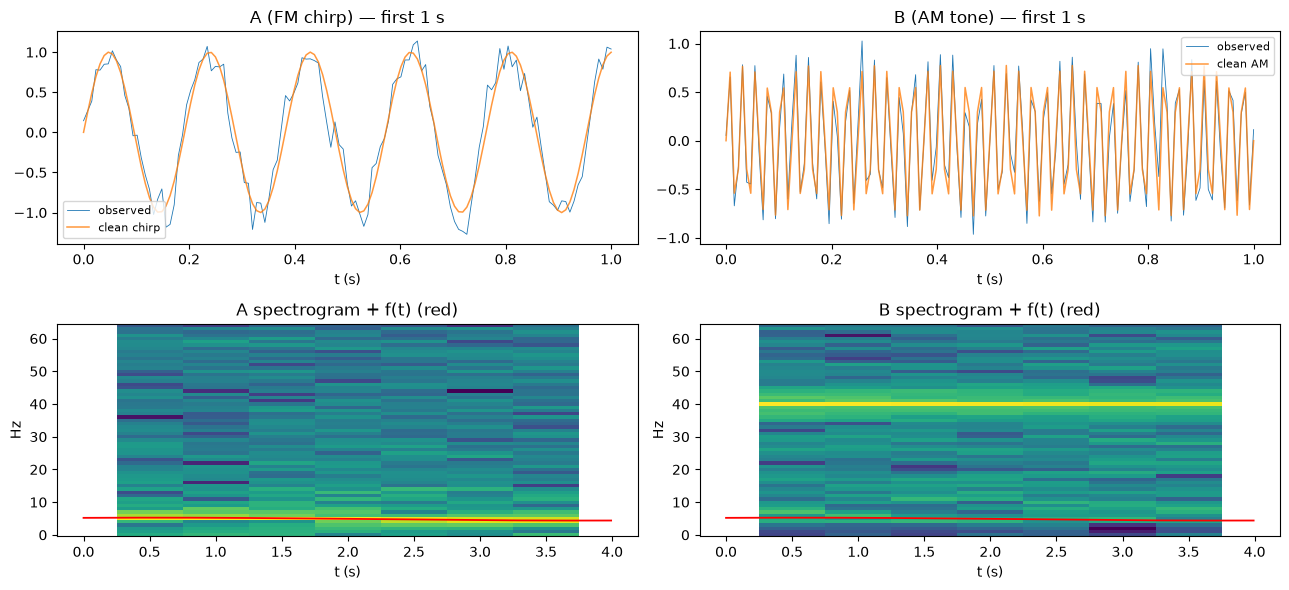

Note: A's energy ridge follows f(t). B's energy sits at the 40 Hz carrier; f(t) is in its envelope (sidebands), not at the f(t) frequency.


In [3]:
# Full anatomy of the corresponding (label=1) pair.
fig, ax = plt.subplots(2, 2, figsize=(13, 6))
wA = pos.t_A <= 1.0; wB = pos.t_B <= 1.0
ax[0,0].plot(pos.t_A[wA], pos.A[wA], lw=.6, label='observed')
ax[0,0].plot(pos.t_A[wA], pos.clean_A[wA], lw=1.1, alpha=.8, label='clean chirp')
ax[0,0].set_title('A (FM chirp) — first 1 s'); ax[0,0].set_xlabel('t (s)'); ax[0,0].legend(fontsize=8)
ax[0,1].plot(pos.t_B[wB], pos.B[wB], lw=.6, label='observed')
ax[0,1].plot(pos.t_B[wB], pos.clean_B[wB], lw=1.1, alpha=.8, label='clean AM')
ax[0,1].set_title('B (AM tone) — first 1 s'); ax[0,1].set_xlabel('t (s)'); ax[0,1].legend(fontsize=8)
for a, smp_t, smp_x, rate, f_t, f_v, title in [
        (ax[1,0], pos.t_A, pos.A, cfg.modality_a.rate, pos.t_A, pos.f_A, 'A spectrogram + f(t) (red)'),
        (ax[1,1], pos.t_B, pos.B, cfg.modality_b.rate, pos.t_B, pos.f_B, 'B spectrogram + f(t) (red)')]:
    f, tt, Sxx = spectrogram(smp_x, fs=rate, nperseg=128, noverlap=64)
    a.pcolormesh(tt, f, 10*np.log10(Sxx+1e-12), shading='auto')
    a.plot(f_t, f_v, 'r-', lw=1.3)
    a.set_title(title); a.set_xlabel('t (s)'); a.set_ylabel('Hz')
plt.tight_layout(); plt.show()
print('Note: A\'s energy ridge follows f(t). B\'s energy sits at the %g Hz carrier;'
      ' f(t) is in its envelope (sidebands), not at the f(t) frequency.' % cfg.modality_b.carrier)

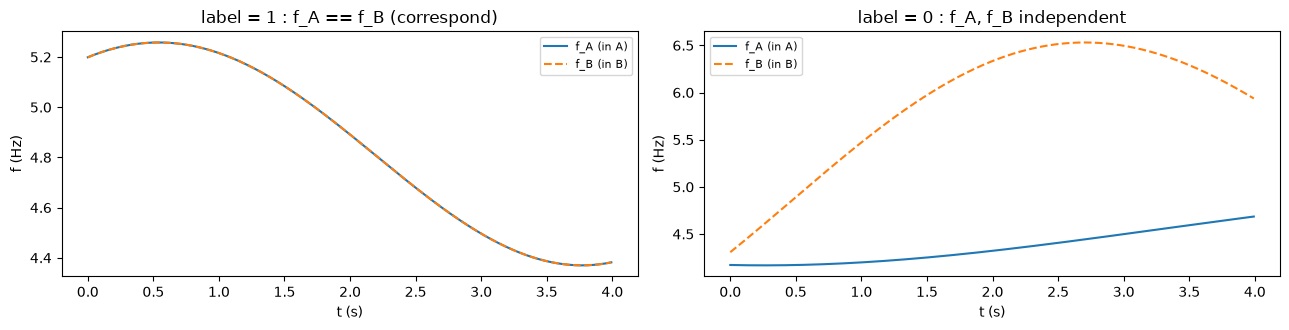

In [4]:
# The hidden factor: f_A vs f_B for the two classes. This IS the label.
fig, axes = plt.subplots(1, 2, figsize=(13, 3.4))
for a, smp, title in [(axes[0], pos, 'label = 1 : f_A == f_B (correspond)'),
                      (axes[1], neg, 'label = 0 : f_A, f_B independent')]:
    a.plot(smp.t_A, smp.f_A, label='f_A (in A)')
    a.plot(smp.t_B, smp.f_B, '--', label='f_B (in B)')
    a.set_title(title); a.set_xlabel('t (s)'); a.set_ylabel('f (Hz)'); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 2. The task

**What a model sees:** only the four arrays `A, t_A, B, t_B`. It never sees f(t).

### (a) Accuracy — the main task (binary correspondence)
Predict the **label**: *do A and B carry the same trajectory f(t)?* (1 = yes, 0 = no).
Accuracy = fraction correct on a held-out test split; chance ≈ 0.5. Crucially the label
is **joint-only**: neither A alone nor B alone predicts it (verified in Phase 2, C1) —
each modality's own f(t) is always a fresh random draw, so only the *coupling* differs.
The model must *compare* the two modalities. That is what makes this a fusion problem.

### (b) Probe — the diagnostic (why a method works)
Freeze a trained model's internal representation **z**, then train a small regressor to
recover the ground-truth trajectory **f(t)** from z, and report **R²**. This *factors*
the question: if z doesn't even encode f(t) (low R²), fusion has nothing to compare;
if z encodes it well (high R²) but accuracy is poor, the fusion head is the bottleneck.

Below: the "thing we're trying to find" made visible — the oracle correspondence
statistic (correlation between f_A and f_B) cleanly separates the two classes.

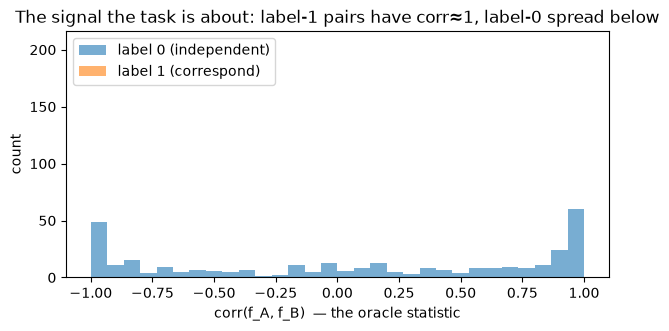

A model must recover this WITHOUT seeing f — only from the noisy A,B observations.


In [5]:
# What separates the classes: correlation between the two trajectories.
def corr_stat(smp):
    f_b_on_a = np.interp(smp.t_A, smp.t_B, smp.f_B)
    return float(np.corrcoef(smp.f_A, f_b_on_a)[0, 1])

c1, c0 = [], []
for s in range(600):
    smp = generate(cfg, s)
    (c1 if smp.label == 1 else c0).append(corr_stat(smp))
plt.figure(figsize=(7, 3.2))
plt.hist(c0, bins=30, alpha=.6, label='label 0 (independent)')
plt.hist(c1, bins=30, alpha=.6, label='label 1 (correspond)')
plt.xlabel('corr(f_A, f_B)  — the oracle statistic'); plt.ylabel('count'); plt.legend()
plt.title('The signal the task is about: label-1 pairs have corr≈1, label-0 spread below')
plt.show()
print('A model must recover this WITHOUT seeing f — only from the noisy A,B observations.')

## 3. SNR — what it means and why it is the key knob

**SNR (dB) = 10·log10( var(clean signal) / var(background noise) ).** The generator
scales the noise to hit the configured SNR exactly. High SNR → the f(t)-carrying signal
dominates; low SNR → it is buried under the multiscale background. The hypothesis is
that **pooling-based late fusion discards the fine matching component once SNR drops**,
while neural-field latents (trained to reconstruct) keep it. Watch the clean chirp get
swallowed:

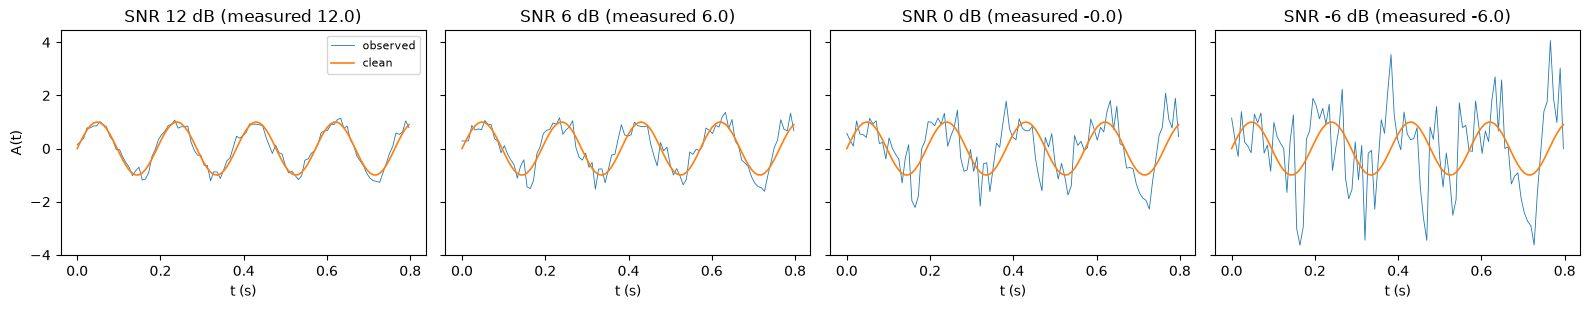

In [6]:
# Same trajectory (fixed seed), increasing noise (lower SNR).
seed1 = next(s for s in range(400) if generate(cfg, s).label == 1)
levels = [12, 6, 0, -6]
fig, axes = plt.subplots(1, 4, figsize=(16, 3.2), sharey=True)
for a, snr in zip(axes, levels):
    c = dataclasses.replace(cfg, snr_db=float(snr))
    smp = generate(c, seed1, return_components=True)
    w = smp.t_A <= 0.8
    a.plot(smp.t_A[w], smp.A[w], lw=.6, label='observed')
    a.plot(smp.t_A[w], smp.clean_A[w], lw=1.2, label='clean')
    meas = 10*np.log10(smp.clean_A.var() / smp.noise_A.var())
    a.set_title(f'SNR {snr} dB (measured {meas:.1f})'); a.set_xlabel('t (s)')
axes[0].legend(fontsize=8); axes[0].set_ylabel('A(t)')
plt.tight_layout(); plt.show()

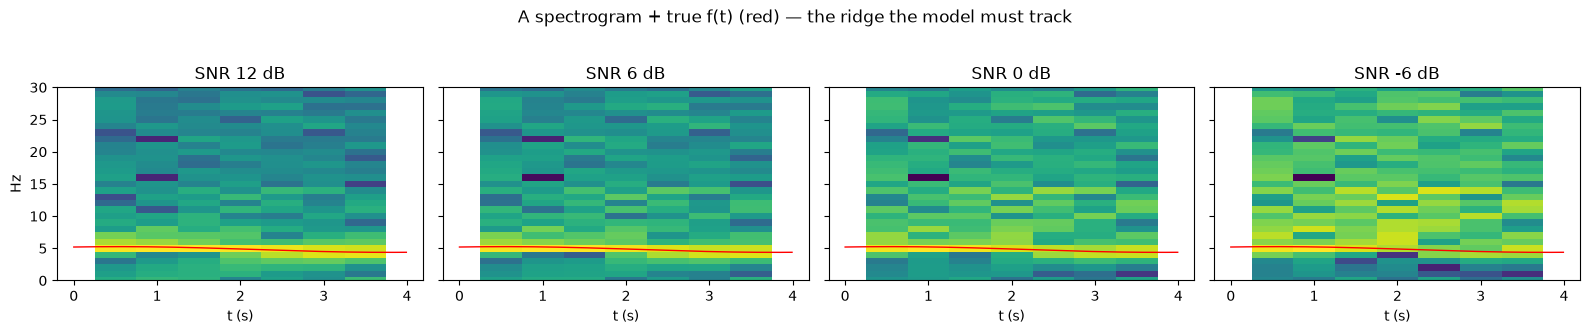

In [7]:
# Same story in the time-frequency view: the f(t) ridge fades into the background.
fig, axes = plt.subplots(1, 4, figsize=(16, 3.2), sharey=True)
for a, snr in zip(axes, levels):
    c = dataclasses.replace(cfg, snr_db=float(snr))
    smp = generate(c, seed1, return_components=True)
    f, tt, Sxx = spectrogram(smp.A, fs=cfg.modality_a.rate, nperseg=128, noverlap=64)
    a.pcolormesh(tt, f, 10*np.log10(Sxx+1e-12), shading='auto')
    a.plot(smp.t_A, smp.f_A, 'r-', lw=1.0)
    a.set_ylim(0, 30); a.set_title(f'SNR {snr} dB'); a.set_xlabel('t (s)')
axes[0].set_ylabel('Hz')
plt.suptitle('A spectrogram + true f(t) (red) — the ridge the model must track', y=1.03)
plt.tight_layout(); plt.show()

## 4. The other variations (difficulty knobs)

Each knob isolates a different reason the matching component is hard to keep.

- **Nonstationarity** (`trajectory.nu_max`): how fast/wiggly f(t) is. A smooth f(t) is
  summarizable by a few numbers (pooling survives); a wiggly one is not.
- **Rate mismatch** (`rate_A` vs `rate_B`): the two modalities live on *different grids*.
  Grid-bound encoders must cope; field methods query a shared continuous coordinate.
- **Jitter**: irregular sample times — the grid isn't even uniform.

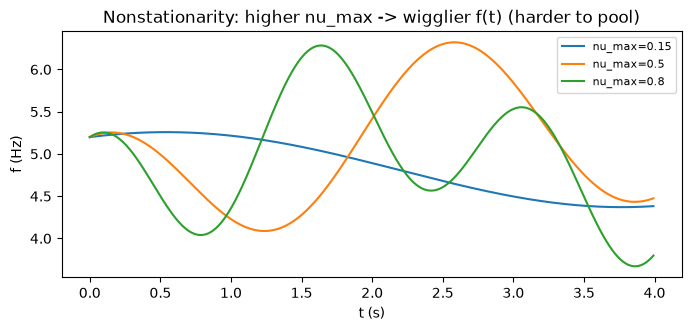

In [8]:
# Nonstationarity: f(t) for increasing nu_max (same seed).
fig, ax = plt.subplots(1, 1, figsize=(8, 3.2))
for nu in [0.15, 0.5, 0.8]:
    c = dataclasses.replace(cfg, trajectory=dataclasses.replace(cfg.trajectory, nu_max=nu))
    smp = generate(c, seed1)
    ax.plot(smp.t_A, smp.f_A, label=f'nu_max={nu}')
ax.set_title('Nonstationarity: higher nu_max -> wigglier f(t) (harder to pool)')
ax.set_xlabel('t (s)'); ax.set_ylabel('f (Hz)'); ax.legend(fontsize=8); plt.show()

hard config: rate_A=160.0 -> 640 samples; rate_B=96.0 -> 384 samples; jitter=0.02


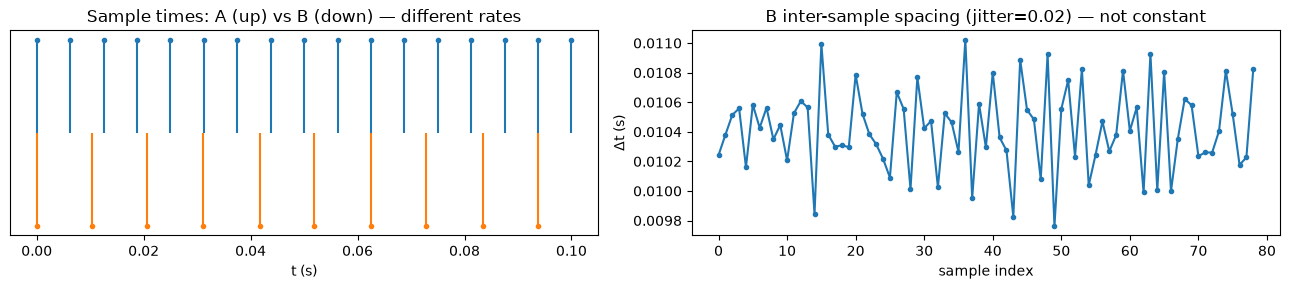

In [9]:
# Rate mismatch + jitter: the two modalities are sampled differently.
hard = load_experiment('../configs/hard.yaml').data
sh = generate(hard, 0)
print(f'hard config: rate_A={hard.modality_a.rate} -> {sh.A.shape[0]} samples; '
      f'rate_B={hard.modality_b.rate} -> {sh.B.shape[0]} samples; jitter={hard.jitter}')
fig, ax = plt.subplots(1, 2, figsize=(13, 3))
m = sh.t_A <= 0.1
ax[0].stem(sh.t_A[m], np.ones(m.sum()), linefmt='C0-', markerfmt='C0.', basefmt=' ')
mb = sh.t_B <= 0.1
ax[0].stem(sh.t_B[mb], -np.ones(mb.sum()), linefmt='C1-', markerfmt='C1.', basefmt=' ')
ax[0].set_title('Sample times: A (up) vs B (down) — different rates'); ax[0].set_xlabel('t (s)')
ax[0].set_yticks([])
# jitter: spacing of B is not constant when jitter>0
ax[1].plot(np.diff(sh.t_B[:80]), '.-')
ax[1].set_title(f'B inter-sample spacing (jitter={hard.jitter}) — not constant')
ax[1].set_xlabel('sample index'); ax[1].set_ylabel('Δt (s)')
plt.tight_layout(); plt.show()

## Takeaway

- **Accuracy** asks: *can the method tell whether A and B share f(t)?*
- **Probe-R²** asks: *did the method's representation even keep f(t)?* — the mechanism.
- **SNR / nonstationarity / rate-mismatch / jitter** dial *how buried and how hard-to-pool*
  the matching component is.

The headline result: as SNR drops and f(t) gets wigglier, pooled late fusion's accuracy
and its probe-R² both collapse, while the LAINR neural field keeps a high probe-R² and
degrades gracefully — i.e. it *preserves the fine matching component that pooling throws
away*. See `archive/2026-06-29_nf-fusion-study/EXTENDED_ABSTRACT.md`.